<div style="background-color:#0B3C5D; padding:25px; border-radius:10px;">

![](https://raw.githubusercontent.com/wateraccounting/WaPORMOOC/main/images/banner_notebooks_WaPOR4Global.png)


<div style="text-align:center; margin-top:15px;">
<h3 style="color:#D9E6F2; margin-bottom:5px;">
<i>Visualising WaPOR Analyses <br></i><b>From Country to Field &mdash; Iraq</b>
</h3>

<p style="color:white; margin-top:5px;">
<b>Estimated time:</b> 1 hour &nbsp;
</p>
</div>

</div>

---

## 📚 Course Information

| Item | Description |
|------|-------------|
| **Course** | MOOC - WaPOR for Global Challenges |
| **Module** | 3 &mdash; Visualising WaPOR analyses |
| **Covers** | Lessons 1&ndash;3 (Exercises 1&ndash;3): Time-series, & Cropland  |
| **Scale** | Country (18 governorates) &rarr; Cropland (Erbil)
| **Data** |  WaPOR L1 monthly; WaPOR L3 monthly |

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Visualize** spatial and temporal patterns of rainfall, reference ET and WaPOR variables across scales.
2. **Compare** climate and cropland behaviour between locations using the right chart type for each question.
3. **Choose** colormaps, shared axes and uncertainty representations deliberately, and recognise common pitfalls.
4. **Visualize forecasts and their uncertainty** at field level (forecast overlays, confidence ribbons, model-comparison dashboards, forecast-quality maps).

---

> **How to read this notebook.** Each chart is followed by a **🔍 Visualization Lens** box (what the chart shows, what works, what to watch for, what to improve, plus a quick quiz) and often an orange **💬 Forum** box with a hands-on task.
---

## 📖 Table of Contents
1. Environment Setup
2. Input Data Preparation
3. Erbil Cropland — WaPOR Satellite Analysis
4. The Four WaPOR Signals
5. Water Supply vs. Demand
6. Drought Calendar — Month × Year Heatmaps
7. Water Productivity (NPP / AETI)
8. Year-by-Year Water Budget Summar
9. Spatial Patterns — Mapping the Differences


---

## ⚙️ 1. Environment Setup
<p style="margin-top:1px;">
	Some Python packages are required that may not be included in a basic Python installation. Run the cells below to set up your environment.
	</p>

In [1]:
# =============================================================================
# Install the required packages
# =============================================================================

%%capture
!pip install numpy pandas matplotlib seaborn scipy
!pip install geopandas          # Optional — for map visualisation


In [6]:
# =============================================================================
# Import packages
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import os, zipfile
import warnings
from datetime import datetime

# Optional: spatial mapping
try:
    import geopandas as gpd
    GPD_AVAILABLE = True
    print("✅ geopandas loaded")
except ImportError:
    GPD_AVAILABLE = False
    print("ℹ️ geopandas not installed — map sections will be skipped")

# --- Configuration ---
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("\n✅ Setup complete — Pandas " + pd.__version__ + ", NumPy " + np.__version__)
print("📅 Analysis date: " + datetime.now().strftime('%Y-%m-%d'))


✅ geopandas loaded

✅ Setup complete — Pandas 2.2.2, NumPy 2.0.2
📅 Analysis date: 2026-06-02


## ⚙️ 2. Input data preparation
<p style="margin-top:1px;">
Create folders for where to upload the input data and where to store the results.


In [7]:
# =============================================================================
# DATA FOLDER SETUP
# =============================================================================

data_folder   = 'data'
output_folder = 'output_data'
os.makedirs(data_folder,   exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

## Upload the data files
Place the following data* files in a new folder called `data/`:

Before running the codes, ensure that you have uploaded the following files in the `data/` folder:



**Expected CSV format:** First column = date (`DD/MM/YYYY`), remaining columns = governorate names.

*Instructions on how to download the required data is provided in this [Notebook](notebook link).

---

#  3. Erbil Cropland — WaPOR Satellite Analysis

Notebook2a used AgERA5 climate reanalysis data at country scale. This section zooms into Erbil governorate using four WaPOR satellite-derived variables extracted for land cover class 40 (cropland), covering 2018–2025:

| Variable | Description | Units |
|---|---|---|
| **PCP** | Precipitation | mm/month |
| **RET** | Reference ET (Penman-Monteith) | mm/month |
| **AETI** | Actual ET & interception by cropland | mm/month |
| **NPP** | Net Primary Production | gC/m²/month |

PCP and RET are atmospheric forcings (what the climate provides/demands). AETI and NPP are the cropland's response. The relationship between them encodes irrigation dependency and productivity.

| File | Variable | Description |
|------|----------|-------------|
| `irq_admin1_L1-PCP-M_mm_per_month` | PCP* | Monthly precipitation (mm) |
| `irq_admin1_L1-RET-M_mm_per_month` | RET* | Monthly reference ET (mm) |
| `ESA_LC_2021_Erbil_20m_L2-AETI-M_mm_per_month` | AETI** | Monthly actual ET & interception (mm) |
| `ESA_LC_2021_Erbil_20m_L2-NPP-M_gc_per_m2_per_month` | NPP** | Monthly net primary production (gC/m²) |
| `data.zip` | Stats PCP** |Annual and monthly precipitation and reference ET (Penman-Monteith) statistics and inter-annual trends for 18 Iraqi governorates, including mean aridity index values.  |

In [8]:
# Upload data from Notebook_1
from google.colab import files
uploaded = files.upload()

# Save each file to the destination folder
for filename, content in uploaded.items():
    dest_path = f'/content/data/{filename}'
    with open(dest_path, 'wb') as f:
        f.write(content)
    print(f" Saved: {dest_path}")

Saving data.zip to data.zip
 Saved: /content/data/data.zip


In [ ]:

# Upload the `data.zip` exported from Notebook_2 before running this cell.
#
#   Colab: Files panel (left sidebar) → drag `data.zip` onto the panel → Run.


# --- Extract zip if present ---
_zip_candidates = ['data.zip', 'output_data.zip']
_extracted = False

for _zname in _zip_candidates:
    if os.path.exists(_zname):
        print(f"📦 Found {_zname} — extracting ...")
        with zipfile.ZipFile(_zname) as _zf:
            _zf.extractall('_tmp_extract')
        # Flatten nested folders → move all files into data/
        for _root, _dirs, _files in os.walk('_tmp_extract'):
            for _f in _files:
                if not _f.startswith('.'):
                    _src = os.path.join(_root, _f)
                    _dst = os.path.join(data_folder, _f)
                    if not os.path.exists(_dst):
                        os.rename(_src, _dst)
        # Cleanup temp folder
        import shutil
        shutil.rmtree('_tmp_extract', ignore_errors=True)
        print(f"   ✅ Extraction complete.")
        _extracted = True
        break

if not _extracted:
    print("ℹ️  No zip found — assuming files are already in data/.")

# --- Verify ---
_found = sorted(os.listdir(data_folder)) if os.path.exists(data_folder) else []
if _found:
    print(f"\n✅ {len(_found)} file(s) found in data/:")
    for _f in _found:
        print(f"   · {_f}")
else:
    print("\n⚠️  data/ folder is empty.")
    print("   Upload data.zip via the Files panel (left sidebar) and re-run.")

### Read data files
The `load_wapor_variable` function is run using the following script for each data file. For this exercise you read monthly rainfall, reference ET data, actual ET & interception and net primary production from WaPOR for the period 2018-2025.

Check if for each data set you have data for the entire period.

In [10]:
# =============================================================================
# LOAD ERBIL WaPOR DATA (land cover class 40 = cropland)
# =============================================================================


def _resolve_csv(folder, filename):
    path = os.path.join(folder, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return path

def load_wapor_variable(filepath, var_name, col):
    df_raw = pd.read_csv(filepath)
    date_col = df_raw.columns[0]
    for fmt in ['%d/%m/%Y', '%Y-%m-%d', '%m/%d/%Y']:
        try:
            df_raw[date_col] = pd.to_datetime(df_raw[date_col], format=fmt)
            break
        except (ValueError, TypeError):
            continue
    else:
        df_raw[date_col] = pd.to_datetime(df_raw[date_col], dayfirst=True)

    df_raw.set_index(date_col, inplace=True)
    df_raw.index.name = 'date'
    df_raw = df_raw.sort_index()

    if col not in df_raw.columns:
        raise KeyError(f"Column '{col}' not found. Available: {df_raw.columns.tolist()}")

    series = pd.to_numeric(df_raw[col], errors='coerce')
    series.name = var_name
    print(f"  {var_name}: {len(series)} months | "
          f"{series.index.min().strftime('%b %Y')} — {series.index.max().strftime('%b %Y')} | "
          f"mean {series.mean():.1f}")
    return series

print("Loading WaPOR cropland data for Erbil:")
df_erbil = pd.DataFrame({
    'PCP':  load_wapor_variable(_resolve_csv(data_folder, 'irq_admin1_L1-PCP-M_mm_per_month.csv'),          'PCP',  'Erbil'),
    'RET':  load_wapor_variable(_resolve_csv(data_folder, 'irq_admin1_L1-RET-M_mm_per_month.csv'),          'RET',  'Erbil'),
    'AETI': load_wapor_variable(_resolve_csv(data_folder, 'ESA_LC_2021_Erbil_20m_L2-AETI-M_mm_per_month.csv'), 'AETI', 'Cropland'),
    'NPP':  load_wapor_variable(_resolve_csv(data_folder, 'ESA_LC_2021_Erbil_20m_L2-NPP-M_gc_per_m2_per_month.csv'), 'NPP', 'Cropland'),
})

df_erbil['month'] = df_erbil.index.month
df_erbil['year']  = df_erbil.index.year

print(f"\nCombined: {df_erbil.shape[0]} months x {df_erbil.shape[1]} columns")
print(f"Missing values: {df_erbil[['PCP','RET','AETI','NPP']].isnull().sum().to_dict()}")

Loading WaPOR cropland data for Erbil:
  PCP: 96 months | Jan 2018 — Dec 2025 | mean 64.3
  RET: 96 months | Jan 2018 — Dec 2025 | mean 129.2
  AETI: 96 months | Jan 2018 — Dec 2025 | mean 27.6
  NPP: 96 months | Jan 2018 — Dec 2025 | mean 21.2

Combined: 96 months x 6 columns
Missing values: {'PCP': 0, 'RET': 0, 'AETI': 0, 'NPP': 0}


In [28]:
# =============================================================================
# READ DATA FILES
# =============================================================================

def load_governorate_data(filepath, name=''):
    df_raw = pd.read_csv(filepath)
    date_col = df_raw.columns[0]
    for fmt in ['%d/%m/%Y', '%Y-%m-%d', '%m/%d/%Y', '%Y/%m/%d']:
        try:
            df_raw[date_col] = pd.to_datetime(df_raw[date_col], format=fmt)
            break
        except (ValueError, TypeError):
            continue
    else:
        df_raw[date_col] = pd.to_datetime(df_raw[date_col], dayfirst=True)

    df_raw.set_index(date_col, inplace=True)
    df_raw.index.name = 'date'
    df_raw = df_raw.sort_index()

    # Convert all columns except the index to numeric, coercing errors
    for col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    print(f"  {name}: {df_raw.shape[0]} months | "
          f"{df_raw.index.min().strftime('%b %Y')} — {df_raw.index.max().strftime('%b %Y')} | "
          f"mean {df_raw.mean().mean():.1f} (avg across gov)")
    return df_raw

# --- Load monthly raw data (used to recompute climatology in this notebook) ---
df_rain     = load_governorate_data(_resolve_csv(data_folder, 'irq_admin1_L1-PCP-M_mm_per_month.csv'), name='Rainfall')
rain_annual = load_governorate_data(_resolve_csv(data_folder, 'rain_annual.csv'),      name='Annual Rainfall')

# --- Load pre-computed analysis outputs ---
rain_stats = pd.read_csv(_resolve_csv(data_folder, 'rain_stats.csv'), index_col=0)
rain_trend = pd.read_csv(_resolve_csv(data_folder, 'rain_trend.csv'), index_col='Governorate')
ret_stats  = pd.read_csv(_resolve_csv(data_folder, 'ret_stats.csv'),  index_col=0)
ai_mean    = pd.read_csv(_resolve_csv(data_folder, 'ai_mean.csv'),    index_col=0)

# --- Governorate list (used by every downstream plotting cell) ---
governorates    = df_rain.columns.tolist()
n_gov           = len(governorates)
representatives = ['Duhok', 'Erbil', 'Baghdad']   # north / semi-arid / central
print("\n\U0001f4cd " + str(n_gov) + " governorates: " + str(governorates))
print("   Representative selection: " + str(representatives))
# --- Also load Reference ET raw data (needed for ET small-multiples & seasonal charts) ---
df_ret      = load_governorate_data(_resolve_csv(data_folder, 'irq_admin1_L1-RET-M_mm_per_month.csv'), name='Reference ET')
ret_annual = load_governorate_data(_resolve_csv(data_folder, 'ret_annual.csv'),       name='Annual Reference ET')


  Rainfall: 96 months | Jan 2018 — Dec 2025 | mean 27.4 (avg across gov)
  Annual Rainfall: 46 months | Dec 1980 — Dec 2025 | mean 281.9 (avg across gov)

📍 18 governorates: ['Al-Anbar', 'Al-Basrah', 'Al-Muthanna', 'Al-Najaf', 'Al-Qadissiya', 'Al-Sulaymaniyah', 'Babil', 'Baghdad', 'Diyala', 'Duhok', 'Erbil', 'Kerbala', 'Kirkuk', 'Maysan', 'Ninewa', 'Salah Al-Din', 'Thi Qar', 'Wassit']
   Representative selection: ['Duhok', 'Erbil', 'Baghdad']
  Reference ET: 96 months | Jan 2018 — Dec 2025 | mean 188.5 (avg across gov)
  Annual Reference ET: 46 months | Dec 1980 — Dec 2025 | mean 2237.9 (avg across gov)


# 📊 4. The Four WaPOR Signals

Each variable is a different 'lens' on the same cropped landscape:
PCP is what falls; RET is what the atmosphere could evaporate;
AETI is what the crop actually evaporates; NPP is what the crop produces.
Reading all four together reveals the water–productivity story.

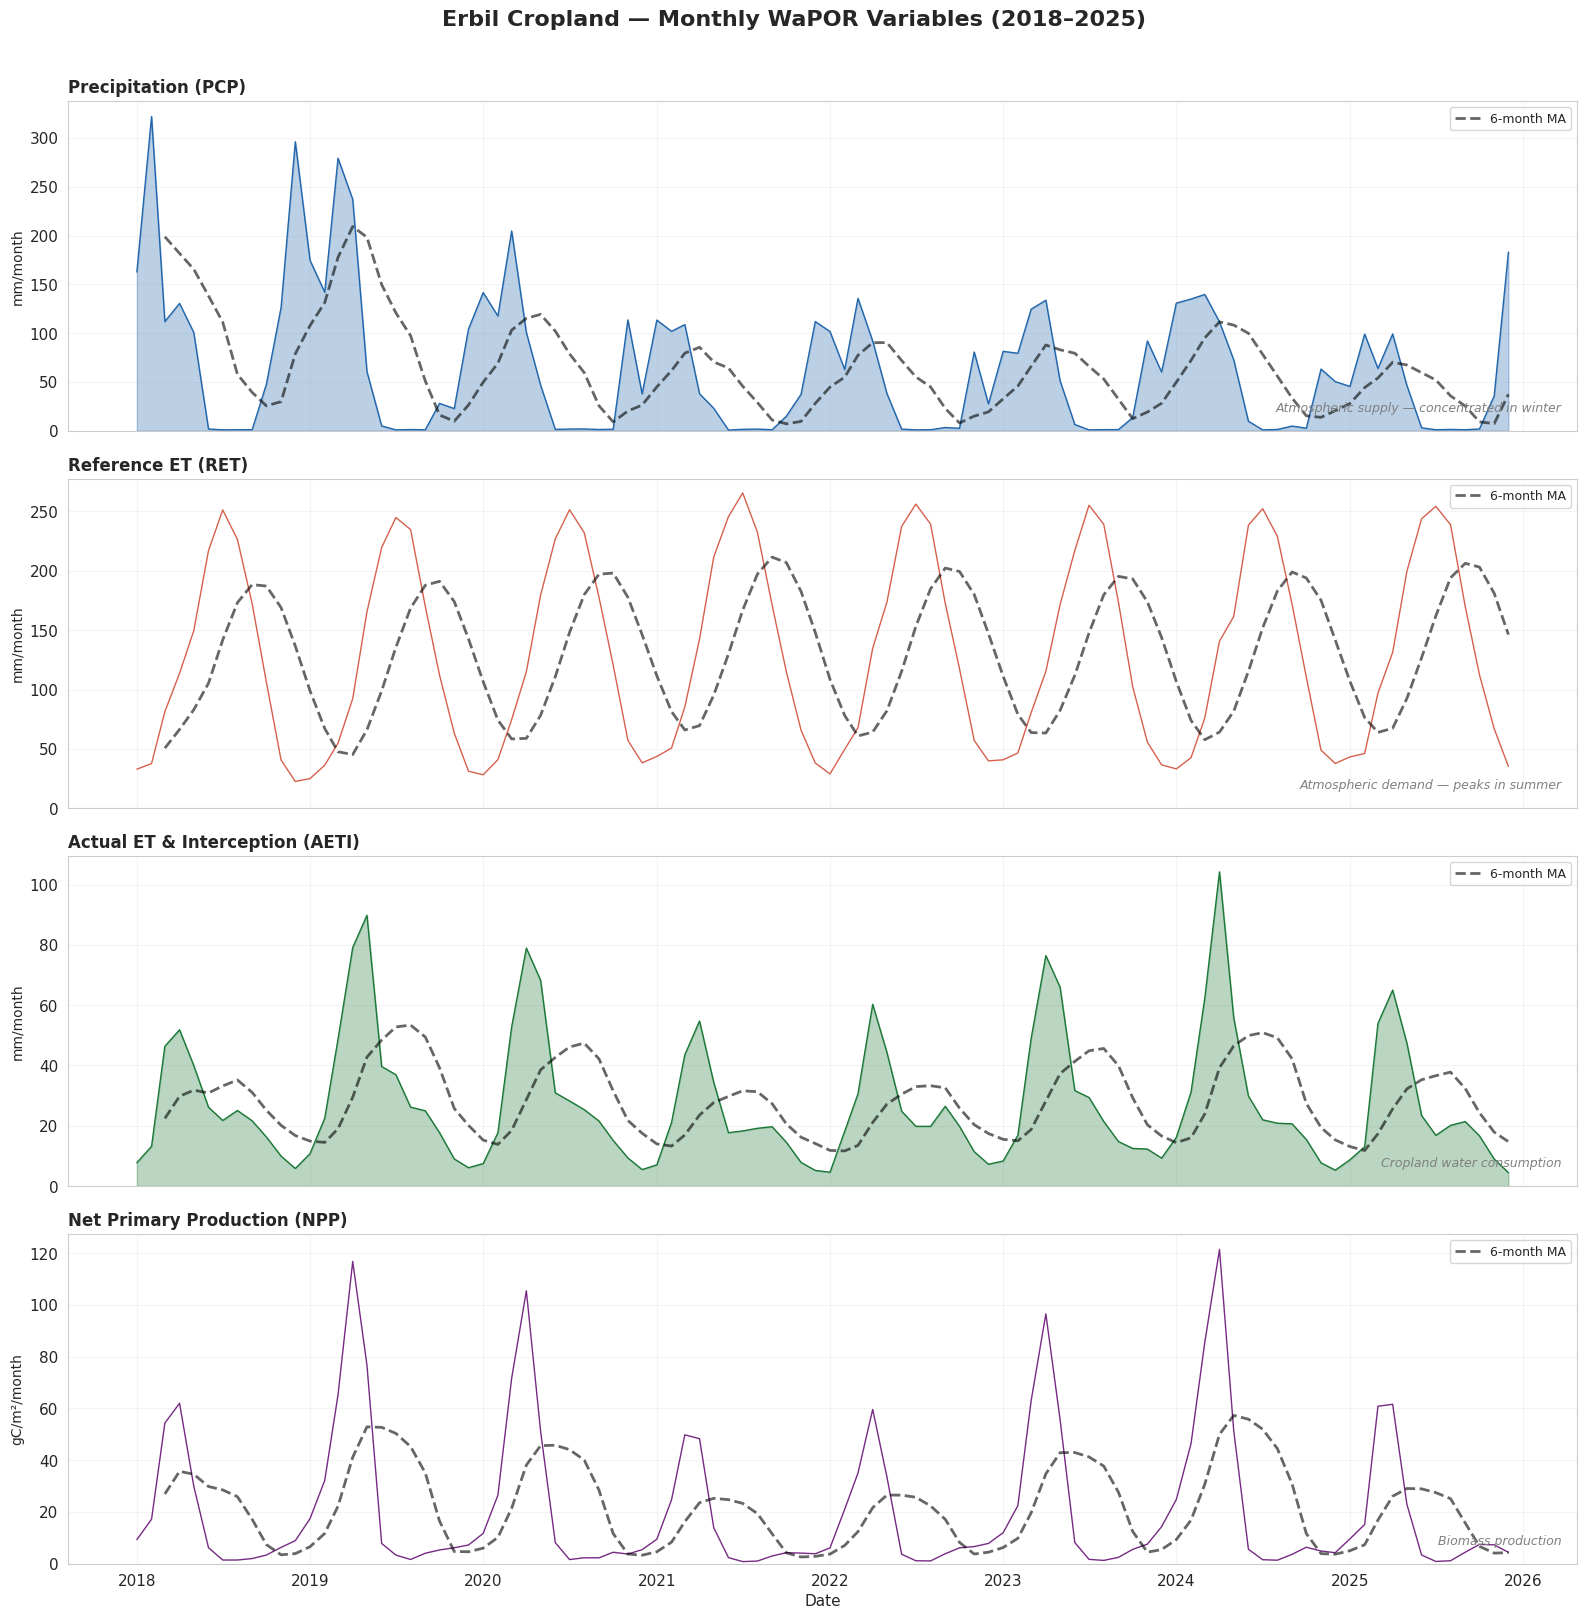

• PCP and AETI are in phase (both peak Nov–Apr).
• RET is anti-phase (peaks Jun–Aug when PCP ≈ 0).
• NPP tracks AETI closely — cropland biomass is water-limited.


In [29]:
# =============================================================================
# THE FOUR WaPOR SIGNALS — STACKED TIME SERIES
# =============================================================================

var_config = {
    'PCP':  {'color': '#2166ac', 'fill': True,  'ylabel': 'mm/month',
             'title': 'Precipitation (PCP)',
             'note': 'Atmospheric supply — concentrated in winter'},
    'RET':  {'color': '#d6604d', 'fill': False, 'ylabel': 'mm/month',
             'title': 'Reference ET (RET)',
             'note': 'Atmospheric demand — peaks in summer'},
    'AETI': {'color': '#1b7837', 'fill': True,  'ylabel': 'mm/month',
             'title': 'Actual ET & Interception (AETI)',
             'note': 'Cropland water consumption'},
    'NPP':  {'color': '#762a83', 'fill': False, 'ylabel': 'gC/m\u00b2/month',
             'title': 'Net Primary Production (NPP)',
             'note': 'Biomass production'},
}

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
fig.suptitle('Erbil Cropland — Monthly WaPOR Variables (2018–2025)',
             fontsize=16, fontweight='bold', y=1.01)

for idx, (var, cfg) in enumerate(var_config.items()):
    if var not in df_erbil.columns:
        continue
    ax = axes[idx]
    if cfg['fill']:
        ax.fill_between(df_erbil.index, 0, df_erbil[var], color=cfg['color'], alpha=0.3)
    ax.plot(df_erbil.index, df_erbil[var], color=cfg['color'], linewidth=1)
    ma = df_erbil[var].rolling(6, min_periods=3).mean()
    ax.plot(ma.index, ma, color='black', linewidth=2, linestyle='--',
            alpha=0.6, label='6-month MA')
    ax.set_ylabel(cfg['ylabel'], fontsize=10)
    ax.set_title(cfg['title'], fontsize=12, fontweight='bold', loc='left')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.2)
    ax.set_ylim(bottom=0)
    ax.text(0.99, 0.05, cfg['note'], transform=ax.transAxes,
            fontsize=9, ha='right', va='bottom', style='italic', color='gray')

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

print("\u2022 PCP and AETI are in phase (both peak Nov\u2013Apr).")
print("\u2022 RET is anti-phase (peaks Jun\u2013Aug when PCP \u2248 0).")
print("\u2022 NPP tracks AETI closely — cropland biomass is water-limited.")


>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
>Monthly time series of all four WaPOR variables for Erbil cropland, stacked in one figure with a shared x-axis.
>
>**What works well:**
>A shared x-axis (`sharex=True`) is essential here — any vertical line you draw mentally crosses all four panels at the same date, letting you read a 'column' of values simultaneously. The `fill_between` shading on PCP and AETI adds area encoding to the line, which helps distinguish seasonal volumes visually from the RET line (no fill).
>Using the same consistent color palette across the whole notebook (blue=PCP, red=RET, green=AETI, purple=NPP) builds a visual grammar the reader applies automatically.
>
>**What to watch out for:**
>With only 8 years of data (2018–2025), the 12-month moving average has been replaced with a 6-month window to avoid excessive smoothing of a short record. Always match your smoothing window to the length of the time series — a 12-month MA on 6 years of data suppresses most of the actual signal.
>
>**What could be improved:**
>Annotate specific years of known agricultural stress or policy events (e.g. the 2021 drought) with a vertical line and label. This connects the visualisation to external ground truth and makes the patterns interpretable beyond statistical noise.
>
>---
>
>🔔 **DISCUSS**
>
>**AETI is substantially lower than RET in every summer month.**
>**What does the gap between AETI and RET tell you about cropland water management during the dry season in Erbil, and why would a water manager care about it?**

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ The gap (RET − AETI) is the unmet atmospheric demand — i.e. water stress.**

*When AETI << RET, crops are transpiring far below their potential rate, either because water supply is insufficient or because the land is fallow. In summer, with PCP ≈ 0, any AETI that does occur must come from irrigation or stored soil moisture. A water manager uses this gap to estimate minimum irrigation requirements: if AETI is 40 mm/month and RET is 200 mm/month, the crop is meeting only 20% of potential demand — a strong stress signal. Tracking this ratio over years reveals whether irrigation is improving or declining. Note that WaPOR AETI includes both crop transpiration and direct soil evaporation; in sparse summer stands, a portion of any AETI may be unproductive soil evaporation rather than productive crop water use.*

</details>

>>💬 **Forum**
>>
>>The demo uses a 6-month moving average on 6 years of data. Replot the same four-panel figure but without any moving average. Then replot it with a 12-month MA.
>>
>>For each version, describe what patterns become visible or invisible. Which smoothing level is most useful for identifying *seasonal* patterns vs *inter-annual* trends?
>>
>>Post all three versions side-by-side and your discussion.

# ⚔️ 5.  Water Supply vs. Demand

Three panels show the full water-stress story:

1.   How supply and atmospheric demand compare month by month
2.   Where actual crop consumption sits relative to potential
3.  The cumulative running deficit.


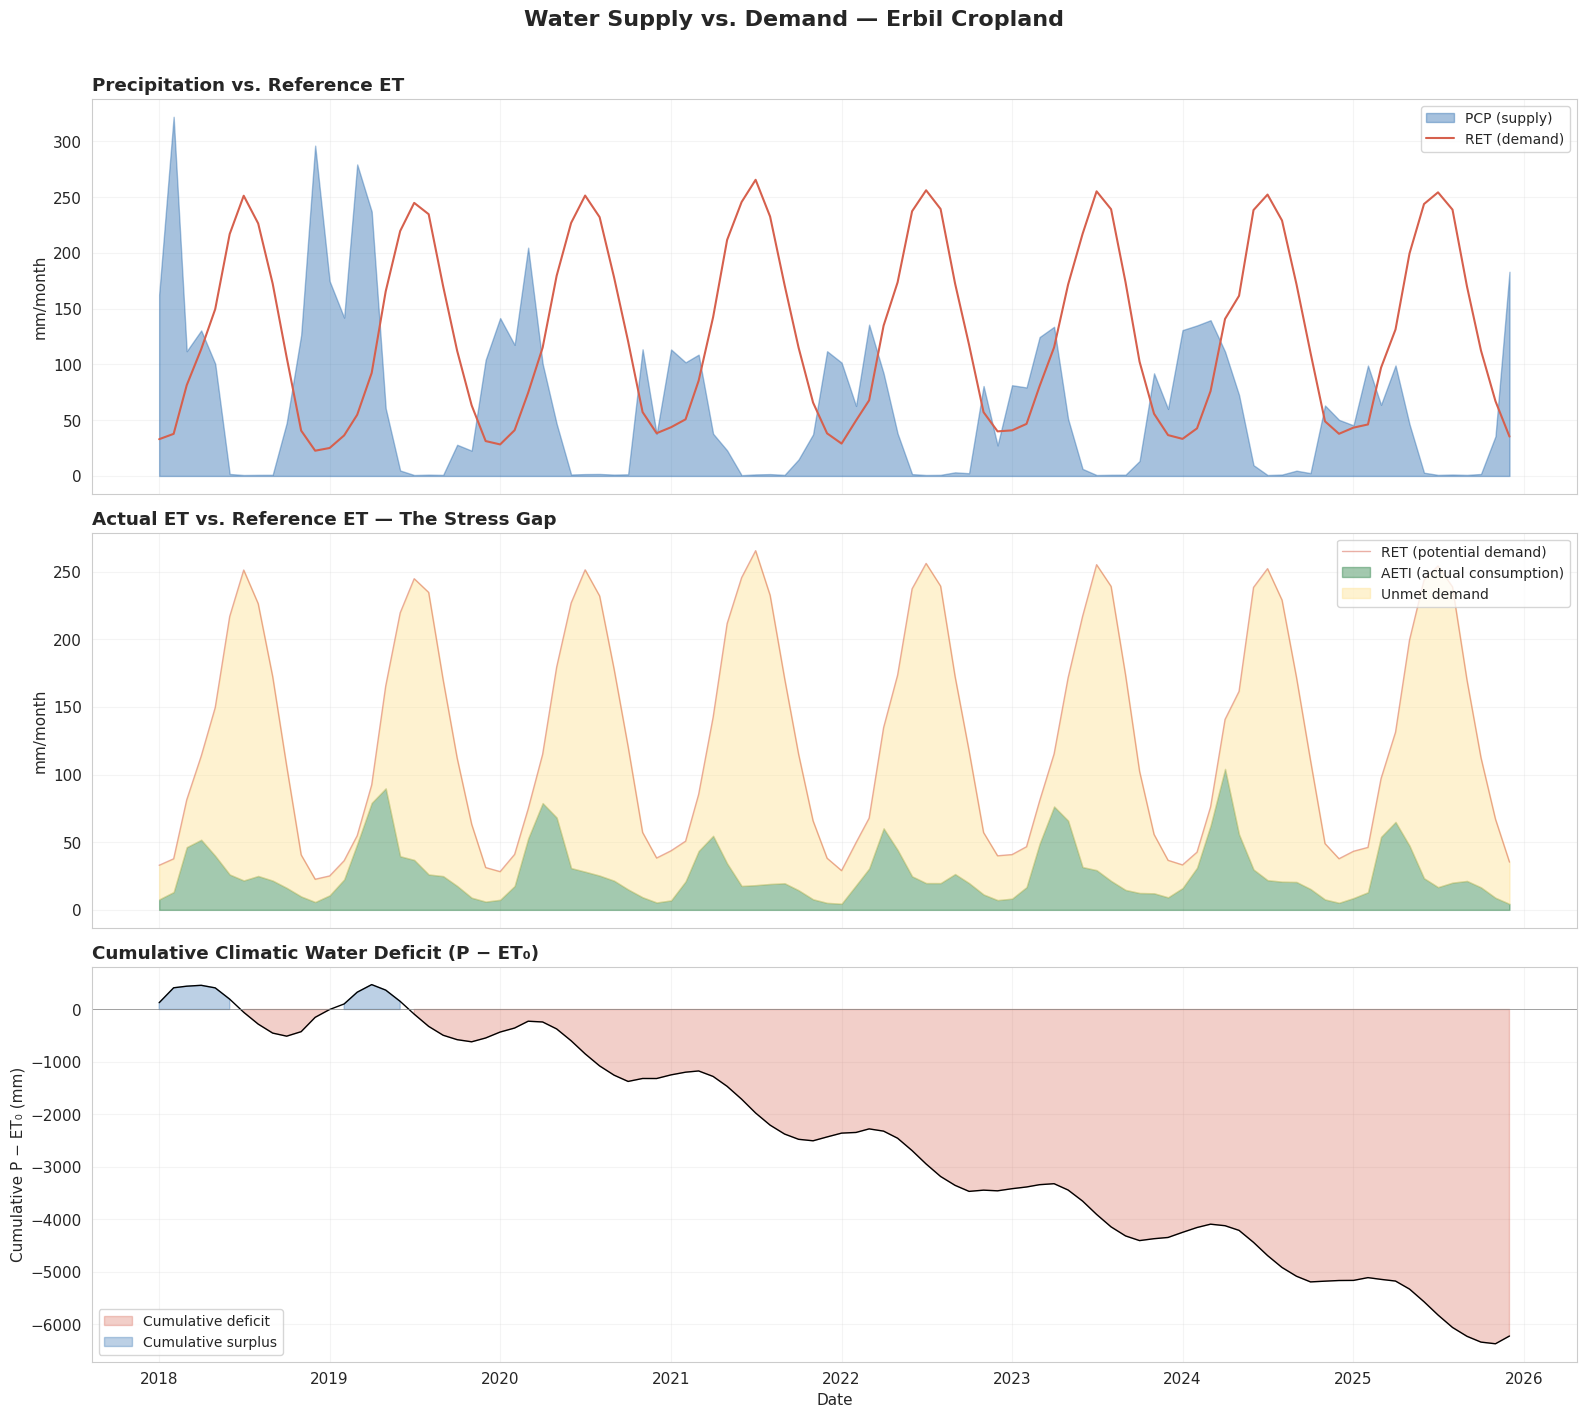

Annual climatic water deficit (PCP − RET):
  🔴 2018: -150 mm (P = 1302, ET₀ = 1452)
  🔴 2019: -394 mm (P = 1056, ET₀ = 1450)
  🔴 2020: -773 mm (P = 770, ET₀ = 1543)
  🔴 2021: -1114 mm (P = 553, ET₀ = 1668)
  🔴 2022: -1028 mm (P = 547, ET₀ = 1575)
  🔴 2023: -890 mm (P = 645, ET₀ = 1534)
  🔴 2024: -821 mm (P = 722, ET₀ = 1543)
  🔴 2025: -1059 mm (P = 580, ET₀ = 1639)


In [30]:
# =============================================================================
# WATER SUPPLY vs. DEMAND — THREE-PANEL FIGURE
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Water Supply vs. Demand — Erbil Cropland',
             fontsize=16, fontweight='bold', y=1.01)

# --- Panel 1: PCP vs RET ---
ax1 = axes[0]
ax1.fill_between(df_erbil.index, 0, df_erbil['PCP'],
                 color='#2166ac', alpha=0.4, label='PCP (supply)')
ax1.plot(df_erbil.index, df_erbil['RET'],
         color='#d6604d', linewidth=1.5, label='RET (demand)')
ax1.set_ylabel('mm/month')
ax1.set_title('Precipitation vs. Reference ET', fontweight='bold', loc='left')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.2)

# --- Panel 2: AETI vs RET with unmet demand shaded ---
ax2 = axes[1]
ax2.plot(df_erbil.index, df_erbil['RET'],
         color='#d6604d', linewidth=1, alpha=0.5, label='RET (potential demand)')
ax2.fill_between(df_erbil.index, 0, df_erbil['AETI'],
                 color='#1b7837', alpha=0.4, label='AETI (actual consumption)')
ax2.fill_between(df_erbil.index, df_erbil['AETI'], df_erbil['RET'],
                 where=df_erbil['RET'] > df_erbil['AETI'],
                 color='#fee08b', alpha=0.4, label='Unmet demand')
ax2.set_ylabel('mm/month')
ax2.set_title('Actual ET vs. Reference ET — The Stress Gap', fontweight='bold', loc='left')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.2)

# --- Panel 3: Cumulative climatic water deficit (PCP - RET) ---
ax3 = axes[2]
cumul = (df_erbil['PCP'] - df_erbil['RET']).cumsum()
ax3.fill_between(df_erbil.index, 0, cumul,
                 where=cumul < 0, color='#d6604d', alpha=0.3, label='Cumulative deficit')
ax3.fill_between(df_erbil.index, 0, cumul,
                 where=cumul >= 0, color='#2166ac', alpha=0.3, label='Cumulative surplus')
ax3.plot(df_erbil.index, cumul, color='black', linewidth=1)
ax3.axhline(y=0, color='gray', linewidth=0.5)
ax3.set_ylabel('Cumulative P \u2212 ET\u2080 (mm)')
ax3.set_title('Cumulative Climatic Water Deficit (P \u2212 ET\u2080)', fontweight='bold', loc='left')
ax3.legend(fontsize=10, loc='lower left')
ax3.grid(True, alpha=0.2)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Annual balance
annual_pcp  = df_erbil['PCP'].resample('YE').sum()
annual_ret  = df_erbil['RET'].resample('YE').sum()
print("Annual climatic water deficit (PCP \u2212 RET):")
for yr in annual_pcp.index:
    deficit = annual_pcp[yr] - annual_ret[yr]
    flag = "\U0001f534" if deficit < 0 else "\U0001f7e2"
    print(f"  {flag} {yr.year}: {deficit:+.0f} mm "
          f"(P = {annual_pcp[yr]:.0f}, ET\u2080 = {annual_ret[yr]:.0f})")


>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
>Three stacked panels: (1) monthly PCP vs RET; (2) AETI vs RET with the unmet demand gap shaded; (3) cumulative climatic water deficit (P − ET₀) over the full period.
>
>**What works well:**
>The `fill_between` technique in panel 2 uses three layers: a green fill for AETI (what crops consumed), a yellow fill for the gap between AETI and RET (what was not met), and a red line for RET. This encoding makes the three quantities — potential demand, actual consumption, and unmet demand — readable simultaneously without bar charts or tables. Panel 3 is the most insightful: the monotonically declining cumulative balance shows that the deficit grows every year — there is no recovery to a neutral balance.
>
>**What to watch out for:**
>The cumulative balance (panel 3) starts at zero by construction — it is the running sum from the first data point. This means the starting level is arbitrary. Do not interpret the absolute value at any point as a physically meaningful quantity. The slope (rate of change) and periods of steepening are what carry information.
>
>**What could be improved:**
>Add an annotation on panel 3 marking each calendar year boundary with a light vertical line and the year label. This allows the reader to read off which year contributed the most to cumulative deficit without counting months manually.
>
>---
>
>🔔 **QUIZ**
>
>**Panel 3 shows the cumulative climatic water deficit (P − ET₀) — the running sum of atmospheric supply minus demand.**
>**Note: this is not a full water balance (which also involves runoff, deep percolation and soil moisture storage).**
>**The curve is almost always declining (negative slope).**
>**What would it mean physically if the curve were *flat* for a full year?**

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ It would mean annual PCP ≈ annual ET₀ for that year — the atmosphere received exactly as much water as it demanded.**

*A flat cumulative curve means the monthly increments (P − ET₀) sum to zero over the year. Given that Iraq's mean annual ET₀ is 1270–2790 mm/yr and mean annual P is 85–880 mm/yr, this condition is never met in practice for any Iraqi governorate. A flat period in the curve would represent an unusually wet year relative to a particularly cool or cloudy year with suppressed ET₀. One methodological note: the deficit ratio uses ET₀ (reference ET for a short-grass surface) as the denominator, not crop ET (ET₀ × Kc). This makes the deficit ratio a conservative upper-bound stress indicator — actual crop demand is lower when the crop coefficient Kc is small (e.g. at harvest or on fallow land).*

</details>

>>💬 **Forum**
>>
>>Panel 2 shades the 'unmet demand' gap between AETI and RET. Compute the **monthly stress ratio** (AETI / RET, clipped to [0, 1]) and plot it as a bar chart over time, coloured by threshold: green (ratio > 0.6), orange (0.3–0.6), red (< 0.3).
>>
>>In which months and years does the cropland experience the most severe stress? How does the stress pattern relate to the PCP time series in panel 1?
>>
>>Post your chart and a short interpretation.

# 🗓️ 6.  Drought Calendar — Month × Year Heatmaps

Restructuring a time series into a year × month matrix makes seasonal and inter-annual patterns visible simultaneously — a technique sometimes called a calendar heatmap or Lasagna plot. Three indices are shown: **SPI** (precipitation-based), **AETI anomaly** (consumption-based), and **deficit ratio** (demand-based).

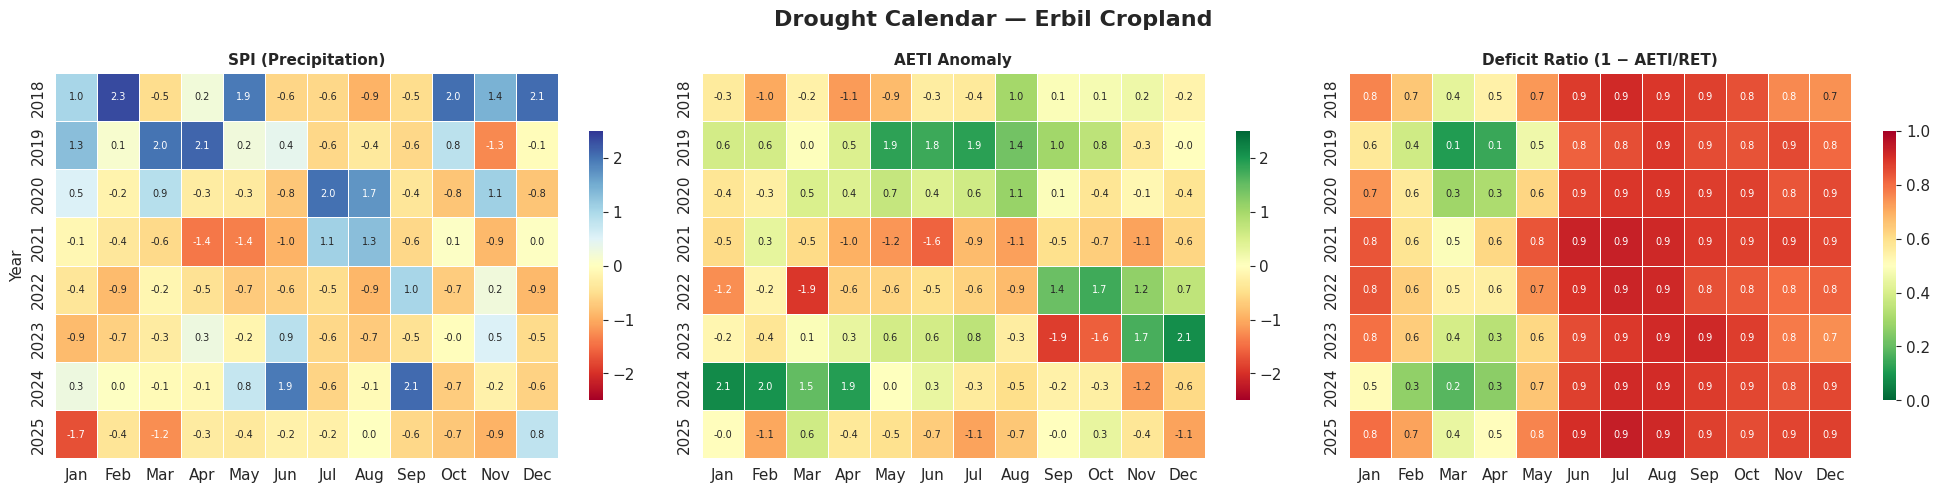

·Months with SPI < −1 (moderate drought):   5
·Months with deficit ratio > 0.7 (severe):   67
·Years where all three indices agree on drought (any month with SPI<-1 AND deficit>0.7):
  [2019, 2021, 2025]


In [31]:
# =============================================================================
# DROUGHT CALENDAR — MONTH × YEAR HEATMAPS
# =============================================================================

# Compute drought indices
monthly_pcp_mean  = df_erbil.groupby('month')['PCP'].transform('mean')
monthly_pcp_std   = df_erbil.groupby('month')['PCP'].transform('std')
df_erbil['SPI']   = ((df_erbil['PCP'] - monthly_pcp_mean) / monthly_pcp_std
                     ).replace([np.inf, -np.inf], np.nan)

monthly_aeti_mean      = df_erbil.groupby('month')['AETI'].transform('mean')
monthly_aeti_std       = df_erbil.groupby('month')['AETI'].transform('std')
df_erbil['AETI_anom']  = ((df_erbil['AETI'] - monthly_aeti_mean) / monthly_aeti_std
                          ).replace([np.inf, -np.inf], np.nan)

df_erbil['deficit_r'] = (1 - df_erbil['AETI'] / df_erbil['RET']).clip(0, 1)

month_names_short = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

indices = [
    ('SPI',        'RdYlBu',   -2.5, 2.5,  0.0,  'SPI (Precipitation)'),
    ('AETI_anom',  'RdYlGn',   -2.5, 2.5,  0.0,  'AETI Anomaly'),
    ('deficit_r',  'RdYlGn_r',  0.0, 1.0,  0.5,  'Deficit Ratio (1 \u2212 AETI/RET)'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, max(5, df_erbil['year'].nunique() * 0.55)))
fig.suptitle('Drought Calendar — Erbil Cropland', fontsize=16, fontweight='bold')

for ax, (col, cmap, vmin, vmax, center, title) in zip(axes, indices):
    pivot = df_erbil.pivot_table(values=col, index='year', columns='month')
    pivot.columns = month_names_short
    sns.heatmap(pivot, cmap=cmap, center=center, vmin=vmin, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5, ax=ax,
                cbar_kws={'shrink': 0.7}, annot_kws={'fontsize': 7})
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Year' if ax is axes[0] else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

spi_drought = (df_erbil['SPI'] < -1).sum()
print(f"·Months with SPI < \u22121 (moderate drought):   {spi_drought}")
print(f"·Months with deficit ratio > 0.7 (severe):   {(df_erbil['deficit_r'] > 0.7).sum()}")
print(f"·Years where all three indices agree on drought (any month with SPI<-1 AND deficit>0.7):")
agree = df_erbil[(df_erbil['SPI'] < -1) & (df_erbil['deficit_r'] > 0.7)]['year'].unique()
print(f"  {sorted(int(y) for y in agree)}")


>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
>Three year × month heatmaps showing different drought indices for Erbil cropland. Each row is one year; each column is one month; cell color encodes index value. Restructuring a linear time series into a calendar matrix reveals seasonality AND inter-annual variation simultaneously — scanning down a single column immediately shows whether that month was consistently wet or dry across years.
>
>**What works well:**
>A line chart of SPI shows the temporal sequence; the calendar heatmap adds the seasonal structure of drought within years. A single glance down the February column replaces 6 individual year comparisons.
>
>**What to watch out for:**
>With only 8 years of data, the SPI is computed from a very short baseline (2018–2025). Standardised anomalies derived from an 8-year period are sensitive to a single outlier year and do not represent the climatological distribution. Interpret SPI values cautiously — a 30-year baseline is standard practice for SPI computation.
>
>**What could be improved:**
>Outline cells where two or more indices simultaneously indicate drought (e.g. SPI < −1 AND deficit ratio > 0.7). Convergence of independent indicators gives higher confidence that a real drought event occurred rather than an artefact of one index. Note: the deficit ratio uses ET₀ as the denominator, not crop ET (Kc × ET₀) — making it a conservative upper-bound indicator rather than an exact crop-stress measure.
>
>---
>
>🔔 **QUIZ**
>
>**The SPI panel uses `RdYlBu`; the deficit ratio panel uses `RdYlGn_r`.**
>**Both use diverging colormaps, but with different color semantics.**
>**For the deficit ratio (0 = no deficit, 1 = total deficit), why is red correctly assigned to *high* values rather than *low* values?**

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ Because high deficit ratio (AETI ≈ 0, crop fully stressed) is the 'bad' condition.**

*The `RdYlGn_r` (reversed) colormap assigns red to high values. A deficit ratio of 1.0 means AETI = 0: the crop consumed no water — the worst possible outcome. For SPI, the convention is: negative = dry = bad, so red is assigned to negative values (low end of the scale). The two panels use different color semantics because the variables encode 'bad' at opposite ends of their scale. Always check which direction 'bad' lies before choosing colormap orientation.*

</details>

>>💬 **Forum**
>>
>>The drought calendar uses a year × month layout. Recreate the SPI panel but reorder the rows to show months (Jan–Dec) on the y-axis and years on the x-axis — a transposed version of the same data.
>>
>>Which orientation makes it easier to answer each of these questions:
>>- **(a)** 'Was 2021 a drought year?'
>>- **(b)** 'Is April consistently drier than March?'
>>
>>Post both versions and explain which question each layout answers better and why.

# 🌱 7. Water Productivity (NPP / AETI)

Water productivity (WP = NPP / AETI) measures how much biomass the cropland produces per unit of water consumed. It integrates the four WaPOR variables into a single efficiency metric. The four-panel figure below shows WP from four complementary perspectives.

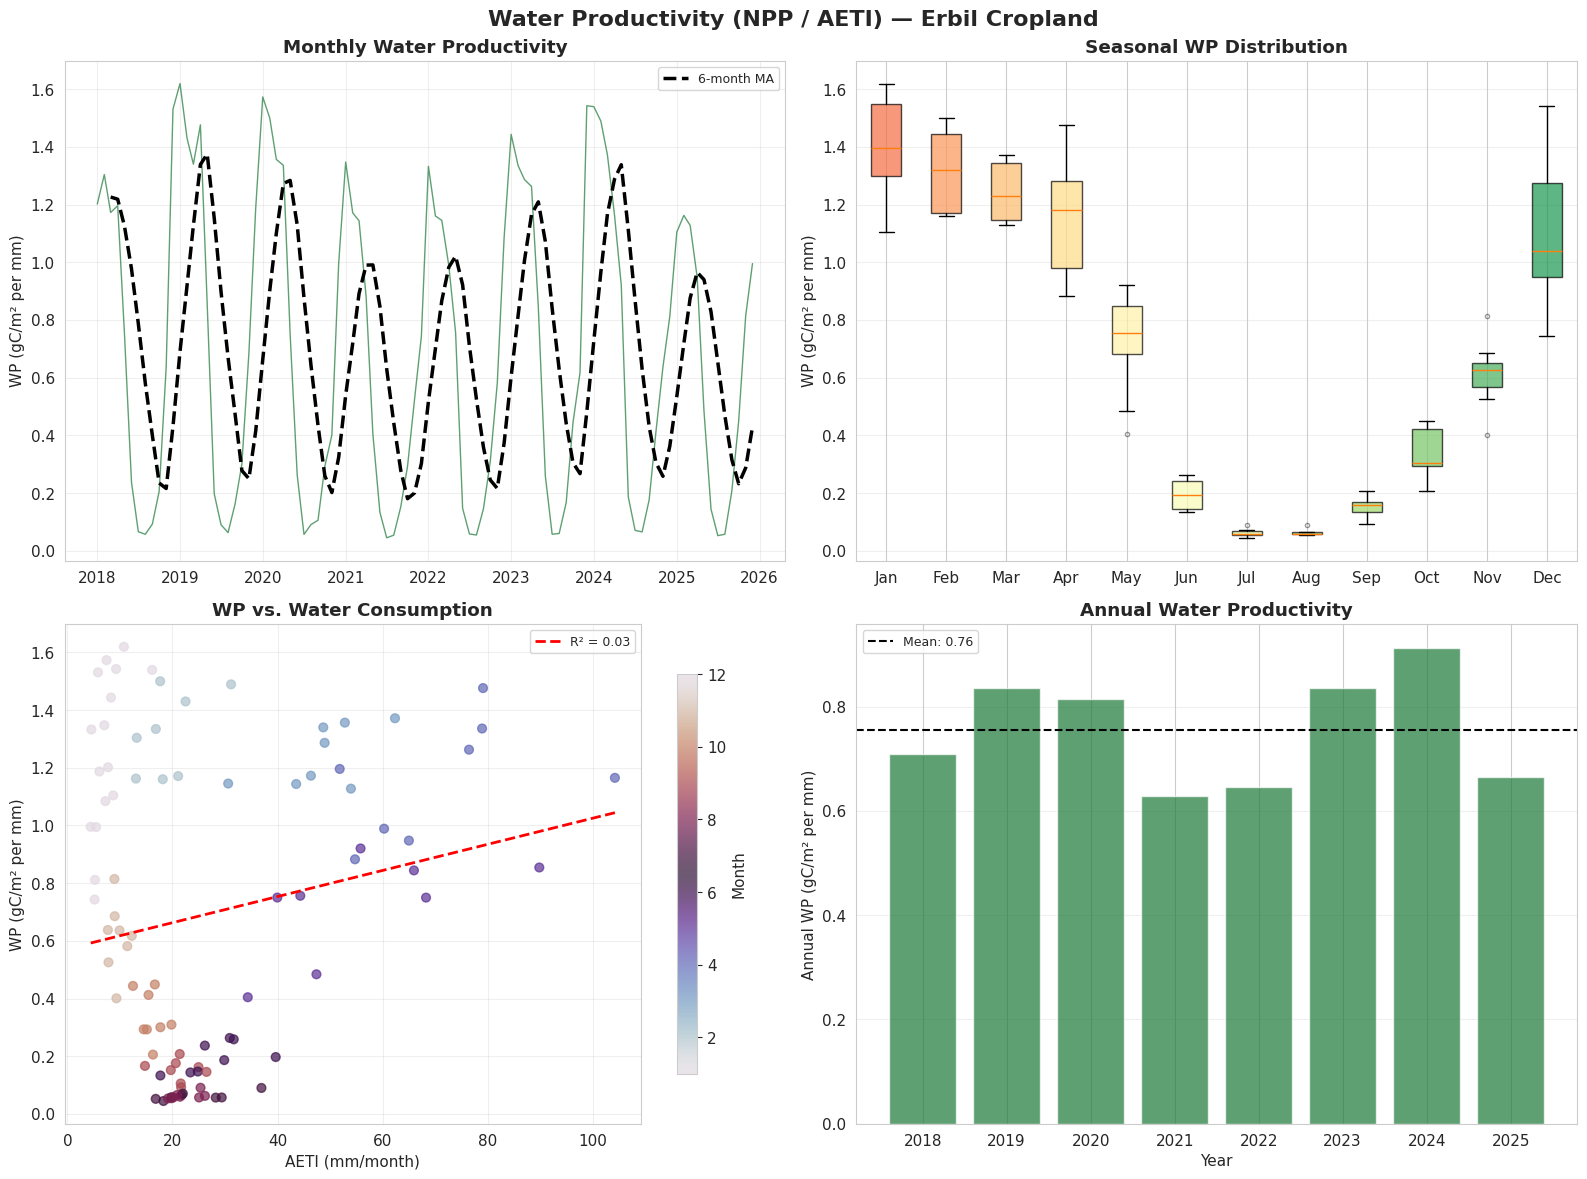

Mean WP: 0.70 gC/m² per mm
Month with highest mean WP: Jan
WP range by year: 0.63 – 0.91 gC/m² per mm


In [32]:
# =============================================================================
# WATER PRODUCTIVITY — NPP / AETI  (gC/m² per mm)
# =============================================================================

if 'NPP' not in df_erbil.columns:
    print("NPP column not found — skipping water productivity section.")
else:
    AETI_MIN = 1.0  # mm/month threshold; avoid division by near-zero
    df_erbil['WP'] = np.where(df_erbil['AETI'] > AETI_MIN,
                               df_erbil['NPP'] / df_erbil['AETI'],
                               np.nan)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Water Productivity (NPP / AETI) — Erbil Cropland',
                 fontsize=16, fontweight='bold')

    month_names_s = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

    # --- Panel 1: WP time series ---
    ax1 = axes[0, 0]
    ax1.plot(df_erbil.index, df_erbil['WP'], color='#1b7837', linewidth=1, alpha=0.7)
    wp_ma = df_erbil['WP'].rolling(6, min_periods=3).mean()
    ax1.plot(wp_ma.index, wp_ma, color='black', linewidth=2.5, linestyle='--',
             label='6-month MA')
    ax1.set_ylabel('WP (gC/m\u00b2 per mm)')
    ax1.set_title('Monthly Water Productivity', fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # --- Panel 2: WP seasonal box plot ---
    ax2 = axes[0, 1]
    wp_valid = df_erbil[df_erbil['WP'].notna()].copy()
    wp_by_month = [wp_valid[wp_valid['month'] == m]['WP'].dropna() for m in range(1, 13)]
    bp = ax2.boxplot(wp_by_month, labels=month_names_s, patch_artist=True,
                     showfliers=True, flierprops={'marker':'o','markersize':3,'alpha':0.4})
    cmap_bp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 12))
    for patch, color in zip(bp['boxes'], cmap_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_ylabel('WP (gC/m\u00b2 per mm)')
    ax2.set_title('Seasonal WP Distribution', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # --- Panel 3: WP vs AETI scatter (month-coloured) ---
    ax3 = axes[1, 0]
    valid = df_erbil[['AETI','NPP','WP','month']].dropna()
    sc = ax3.scatter(valid['AETI'], valid['WP'], c=valid['month'],
                     cmap='twilight', s=40, alpha=0.7)
    plt.colorbar(sc, ax=ax3, label='Month', shrink=0.8)
    if len(valid) > 2:
        from scipy.stats import linregress
        slope_wp, intercept_wp, r_wp, _, _ = linregress(valid['AETI'], valid['WP'])
        x_fit = np.linspace(valid['AETI'].min(), valid['AETI'].max(), 100)
        ax3.plot(x_fit, intercept_wp + slope_wp * x_fit, 'r--', linewidth=2,
                 label=f'R\u00b2 = {r_wp**2:.2f}')
        ax3.legend(fontsize=9)
    ax3.set_xlabel('AETI (mm/month)')
    ax3.set_ylabel('WP (gC/m\u00b2 per mm)')
    ax3.set_title('WP vs. Water Consumption', fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # --- Panel 4: Annual WP ---
    ax4 = axes[1, 1]
    annual_wp = (df_erbil.resample('YE')['NPP'].sum() /
                 df_erbil.resample('YE')['AETI'].sum()).dropna()
    years_wp  = annual_wp.index.year
    ax4.bar(years_wp, annual_wp.values, color='#1b7837', alpha=0.7, edgecolor='white')
    ax4.axhline(annual_wp.mean(), color='black', linewidth=1.5, linestyle='--',
                label=f'Mean: {annual_wp.mean():.2f}')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Annual WP (gC/m\u00b2 per mm)')
    ax4.set_title('Annual Water Productivity', fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"Mean WP: {df_erbil['WP'].mean():.2f} gC/m\u00b2 per mm")
    best_m = month_names_s[int(df_erbil.groupby('month')['WP'].mean().idxmax()) - 1]
    print(f"Month with highest mean WP: {best_m}")
    print(f"WP range by year: {annual_wp.min():.2f} \u2013 {annual_wp.max():.2f} gC/m\u00b2 per mm")


>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
>Water productivity (gC/m² per mm) from four perspectives: raw time series with moving average (top-left), seasonal distribution as box plots (top-right), WP vs AETI scatter coloured by month (bottom-left), and annual WP summary (bottom-right).
>
>**What works well:**
>The four panels are complementary — the time series shows temporal sequence; the boxplot shows seasonal distribution including variability; the scatter reveals whether more water consumed leads to more or less efficient production; the annual bar provides the management-relevant summary. No single panel carries the whole story: each resolves a different aspect of the same variable.
>
>**What to watch out for:**
>The scatter plot (panel 3) colours points by month using a circular colormap (`twilight`). The R² from the linear fit summarises the AETI–WP relationship across all months. But the relationship may be non-linear and the months are not independent observations — **a low R² does not necessarily mean AETI and WP are unrelated**; it may mean the relationship is non-linear or season-dependent.
>
>**What could be improved:**
>Add a colour-coded convex hull or ellipse per season (wet/dry) to the scatter plot. This would show whether the AETI–WP relationship differs between seasons — a much more informative display than a single overall fit line.
>
>---
>
>🔔 **DISCUSS**
>
>**WP is highest in January in the seasonal boxplot (mean WP = 1.40 gC/m² per mm), declining through spring. AETI is moderate in January — not its peak.**
>**What does this suggest about the relationship between water consumption and productivity, and what agronomic mechanism might explain it?**

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ Crop growth efficiency (biomass per unit water) is highest in January when cool-season crops (wheat, barley) are in active vegetative growth.**

*In January, cool temperatures favour photosynthesis over respiration, ET demand is moderate, and cool-season crops are in rapid vegetative growth — producing biomass efficiently per unit of water consumed. By March–April, rising temperatures and ET reduce efficiency. In summer, heat and water stress co-occur, suppressing both NPP and AETI simultaneously. This means 'more water' does not always mean 'more productivity' — the relationship is mediated by temperature and crop phenology. One important caveat: WP here is NPP/AETI, a biomass productivity measure. Harvestable yield requires applying a harvest index (~0.40–0.50 for wheat and barley), so yield-based WP is approximately half the values shown.*

</details>

>>💬 **Forum**
>>
>>The demo computes WP = NPP / AETI at monthly resolution. Aggregate to **annual WP** for each year and compare it against the annual PCP for that year.
>>
>>Is there a positive or negative relationship between annual rainfall and annual WP? Plot a scatter of annual PCP vs annual WP with one point per year and a fitted line.
>>
>>Interpret the slope: does more rainfall lead to more or less efficient water use, and why might that be the case?
>>
>>Post your scatter plot and a three-sentence interpretation.

# 🧮 8. Year-by-Year Water Budget Summary

A three-panel grouped bar + line chart summarises the annual water budget, stress ratio, and water productivity in one figure. This is an effective endpoint visualization for the Erbil section before moving to the spatial map.

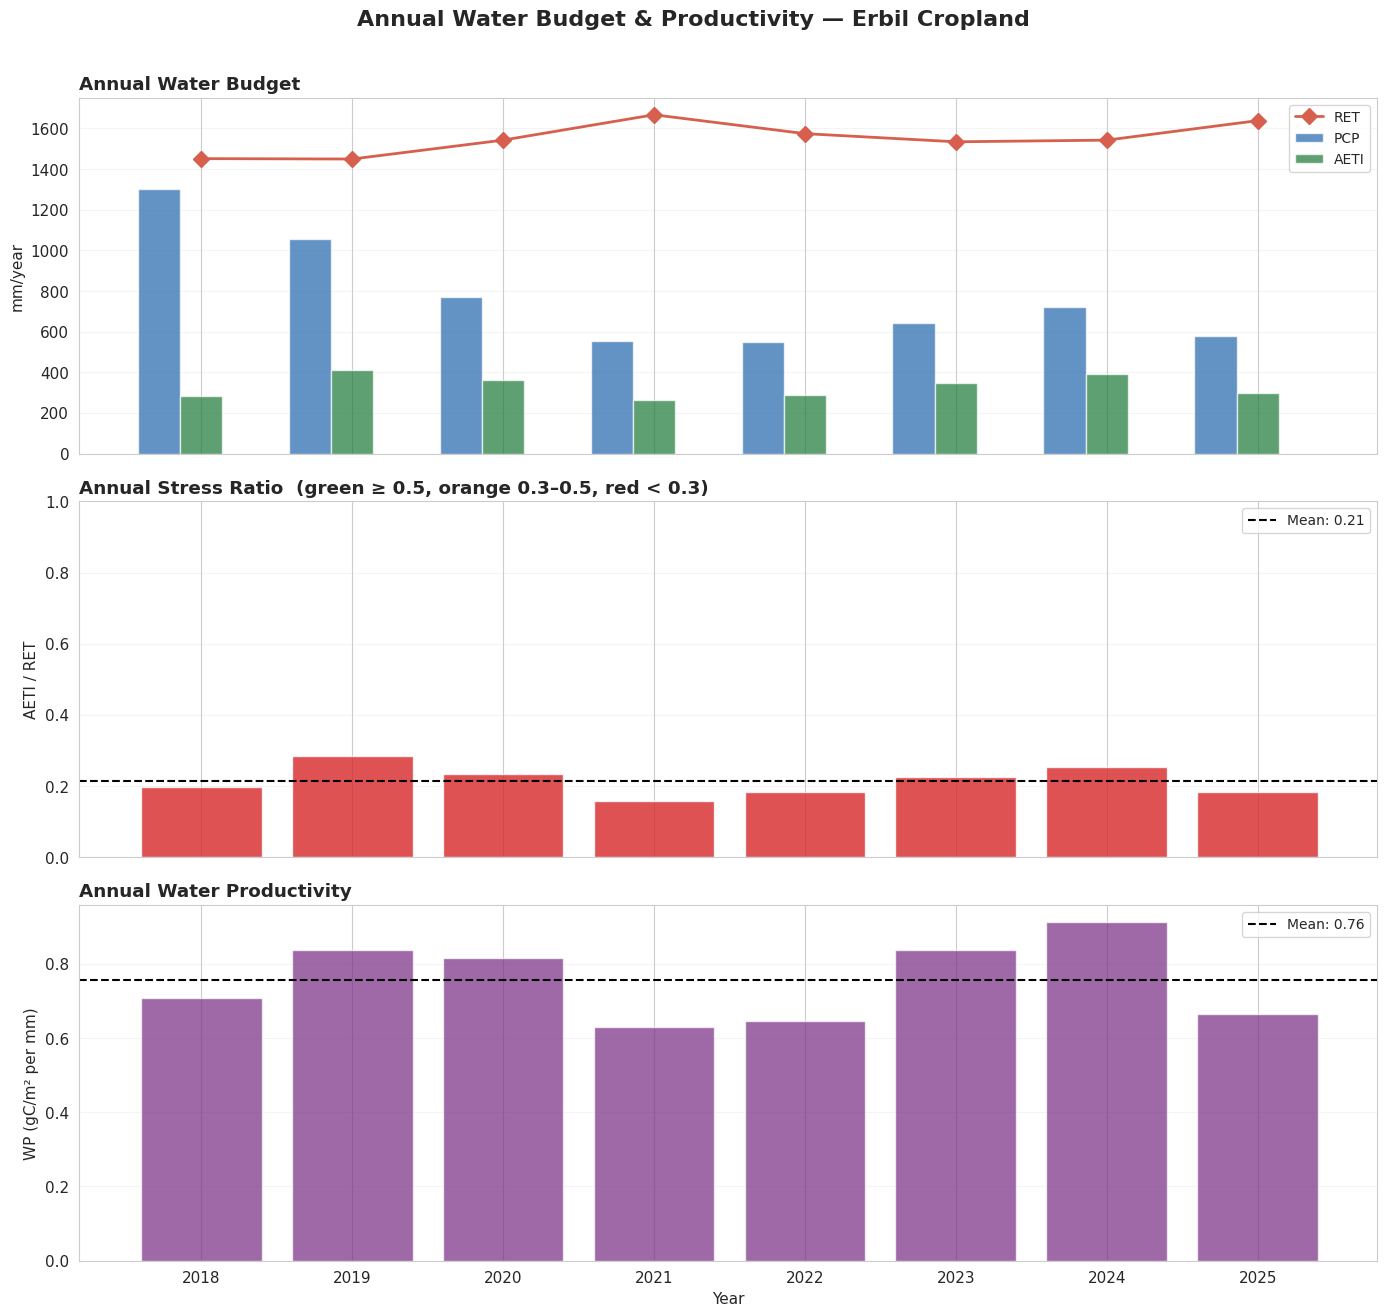

Most productive year:  2024  (WP = 0.91, PCP = 722 mm)
Least productive year: 2021 (WP = 0.63, PCP = 553 mm)


In [33]:
# =============================================================================
# YEAR-BY-YEAR WATER BUDGET SUMMARY
# =============================================================================

if 'NPP' not in df_erbil.columns:
    print("NPP column not found — skipping year-by-year summary.")
else:
    ann = pd.DataFrame({
        'PCP (mm)':    df_erbil.resample('YE')['PCP'].sum(),
        'RET (mm)':    df_erbil.resample('YE')['RET'].sum(),
        'AETI (mm)':   df_erbil.resample('YE')['AETI'].sum(),
        'NPP (gC/m2)': df_erbil.resample('YE')['NPP'].sum(),
    }).dropna()
    ann['AETI/RET'] = ann['AETI (mm)'] / ann['RET (mm)']
    ann['WP']       = ann['NPP (gC/m2)'] / ann['AETI (mm)']
    ann.index       = ann.index.year

    x     = np.arange(len(ann))
    width = 0.28

    fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
    fig.suptitle('Annual Water Budget & Productivity — Erbil Cropland',
                 fontsize=16, fontweight='bold', y=1.01)

    # --- Panel 1: Water budget ---
    ax1 = axes[0]
    ax1.bar(x - width, ann['PCP (mm)'],  width, color='#2166ac', alpha=0.7, label='PCP')
    ax1.bar(x,         ann['AETI (mm)'], width, color='#1b7837', alpha=0.7, label='AETI')
    ax1.plot(x, ann['RET (mm)'], 'D-', color='#d6604d',
             markersize=8, linewidth=2, label='RET')
    ax1.set_ylabel('mm/year')
    ax1.set_title('Annual Water Budget', fontweight='bold', loc='left')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.2, axis='y')

    # --- Panel 2: Stress ratio ---
    ax2 = axes[1]
    bar_colors = ['#2ca02c' if v >= 0.5 else '#ff7f0e' if v >= 0.3 else '#d62728'
                  for v in ann['AETI/RET']]
    ax2.bar(x, ann['AETI/RET'], color=bar_colors, alpha=0.8, edgecolor='white')
    ax2.axhline(ann['AETI/RET'].mean(), color='black', linewidth=1.5, linestyle='--',
                label=f"Mean: {ann['AETI/RET'].mean():.2f}")
    ax2.set_ylabel('AETI / RET')
    ax2.set_title('Annual Stress Ratio  (green \u2265 0.5, orange 0.3\u20130.5, red < 0.3)',
                  fontweight='bold', loc='left')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.2, axis='y')
    ax2.set_ylim(0, 1)

    # --- Panel 3: Water productivity ---
    ax3 = axes[2]
    ax3.bar(x, ann['WP'], color='#762a83', alpha=0.7, edgecolor='white')
    ax3.axhline(ann['WP'].mean(), color='black', linewidth=1.5, linestyle='--',
                label=f"Mean: {ann['WP'].mean():.2f}")
    ax3.set_ylabel('WP (gC/m\u00b2 per mm)')
    ax3.set_xlabel('Year')
    ax3.set_title('Annual Water Productivity', fontweight='bold', loc='left')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.2, axis='y')

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(ann.index)

    plt.tight_layout()
    plt.show()

    best  = ann['WP'].idxmax()
    worst = ann['WP'].idxmin()
    print(f"Most productive year:  {best}  (WP = {ann.loc[best,  'WP']:.2f}, "
          f"PCP = {ann.loc[best,  'PCP (mm)']:.0f} mm)")
    print(f"Least productive year: {worst} (WP = {ann.loc[worst, 'WP']:.2f}, "
          f"PCP = {ann.loc[worst, 'PCP (mm)']:.0f} mm)")


>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
>Three-panel annual summary for Erbil cropland: water budget (PCP, AETI, RET); stress ratio (AETI/RET) colour-coded by severity; and annual water productivity. Grouping three panels with a shared x-axis (years) allows vertical reading — pick a year, scan down, and read the complete story for that year in one pass.
>
>**What works well:**
>The bar + line combination in panel 1 is deliberate: bars encode discrete annual totals (PCP, AETI); the diamond-line for RET differs in geometry to signal it is a demand reference rather than a supply quantity.
>
>**What to watch out for:**
>With only ~6 years of data, each bar represents one year — there is no smoothing. A single outlier year (drought or very wet year) can visually dominate the chart and suggest a trend that is not statistically supported. Always state the record length clearly in the figure title or caption.
>
>**What could be improved:**
>Add a vertical annotation for each year where a named event occurred (e.g. 2021 regional drought, a specific policy change). This grounds the statistical patterns in real events and makes the chart useful beyond the dataset itself.
>
>---
>
>🔔 **QUIZ**
>
>**In the stress ratio panel, every bar is red — AETI/RET never exceeds 0.26 in any year on record.**
>**This means the cropland meets less than 30% of atmospheric demand in every year.**
>**What are two possible explanations for such a persistently low stress ratio (AETI/RET < 0.3), and how would you distinguish between them using other panels in this figure?**

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ Two explanations: (1) insufficient irrigation/rainfall — water limited; (2) low crop cover or fallow land — biomass limited.**

*If water is limiting: PCP will be low (panel 1) and NPP will also be low relative to other years (panel 3, WP may be normal or even high if the remaining crop is efficient). If the land is partly fallow or crop cover is sparse: PCP may be normal, but both AETI and NPP will be low together, and WP may be anomalously high because the surviving crop fraction uses water efficiently. Comparing panels 1, 2, and 3 simultaneously disambiguates the two scenarios.*

</details>

>>💬 **Forum**
>>
>>The demo shows the annual summary for Erbil cropland (class 40). Repeat the water budget panel (Panel 1: PCP, AETI, RET bars + line) for **two other land cover classes** available in the L-series CSVs (e.g. class 20 = shrubland, class 30 = grassland).
>>
>>How does the AETI/RET ratio differ across land cover types in the same year? What does this tell you about the role of land cover in mediating the water balance?
>>
>>Post your two additional figures and a comparative paragraph.

# 🗺️ 9. Spatial Patterns - Mapping the Differences

> *You need the GeoJSON file of Iraq’s governorates to map the results geographically.*

Place your GeoJSON file at `data/irq_admin1.geojson`. **Note that** all statistical analyses above are complete without this part (just a a different form of visualizing the same results that we saw earlier).

In [21]:
# Upload data from Notebook_1
from google.colab import files
uploaded = files.upload()

# Save each file to the destination folder
for filename, content in uploaded.items():
    dest_path = f'/content/data/{filename}'
    with open(dest_path, 'wb') as f:
        f.write(content)
    print(f" Saved: {dest_path}")

Saving irq_admin1.geojson to irq_admin1.geojson
 Saved: /content/data/irq_admin1.geojson


In [22]:
gdf = gpd.read_file(os.path.join(data_folder, 'irq_admin1.geojson'))
print(f"📍 GeoJSON loaded: {len(gdf)} features")

📍 GeoJSON loaded: 18 features


📍 GeoJSON loaded: 18 features


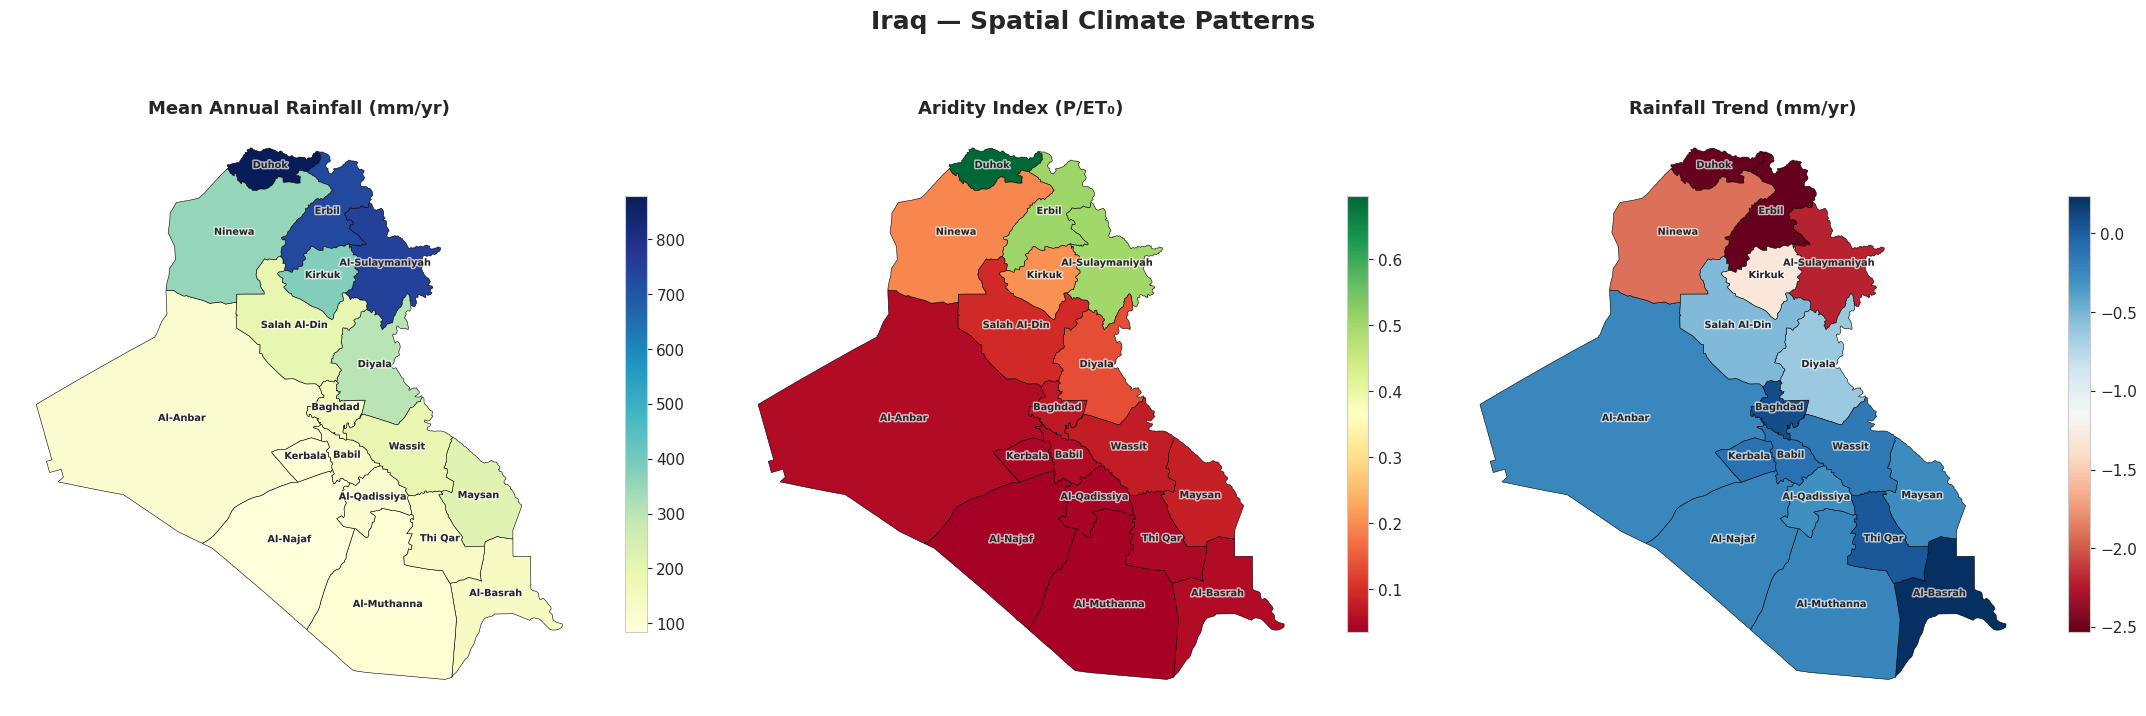

In [35]:
# =============================================================================
# SPATIAL MAPPING (requires geopandas + GeoJSON)
# =============================================================================

import matplotlib.patheffects as pe

if GPD_AVAILABLE:
    gdf = gpd.read_file(os.path.join(data_folder, 'irq_admin1.geojson'))

    print(f"📍 GeoJSON loaded: {len(gdf)} features")

    # Find the name column
    name_col = 'adm1_name' if 'adm1_name' in gdf.columns else None

    if name_col:
        # ai_mean, rain_stats, and rain_trend are now loaded with governorate names as their index.
        # Create a combined DataFrame for easier merging.
        climate_data_for_merge = pd.DataFrame(index=governorates) # Start with all governorates
        climate_data_for_merge.index.name = 'governorate' # Name the index column for merging

        # Populate the DataFrame with relevant data
        # ai_mean's data column is typically named '0' after setting index_col='Unnamed: 0'
        climate_data_for_merge['Aridity_Index'] = ai_mean.iloc[:, 0]
        climate_data_for_merge['Mean_Rainfall'] = rain_stats['mean']
        climate_data_for_merge['Rain_Trend'] = rain_trend['Slope (mm/yr)']

        # Reset index to turn 'governorate' index into a column for GeoDataFrame merge
        final_merge_df = climate_data_for_merge.reset_index()

        gdf_merged = gdf.merge(final_merge_df, left_on=name_col, right_on='governorate', how='left')

        fig, axes = plt.subplots(1, 3, figsize=(22, 8))
        fig.suptitle('Iraq — Spatial Climate Patterns', fontsize=18, fontweight='bold')

        maps_to_plot = [
            ('Mean_Rainfall', 'YlGnBu', 'Mean Annual Rainfall (mm/yr)'),
            ('Aridity_Index', 'RdYlGn', 'Aridity Index (P/ET₀)'),
            ('Rain_Trend', 'RdBu', 'Rainfall Trend (mm/yr)')
        ]

        for i, (col, cmap, title) in enumerate(maps_to_plot):
            ax = axes[i]
            gdf_merged.plot(column=col, cmap=cmap, legend=True,
                           ax=ax, edgecolor='black', linewidth=0.4,
                           missing_kwds={'color': 'lightgray'},
                           legend_kwds={'shrink': 0.6})

            # Add labels using 'adm1_name'
            for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged[name_col]):
                ax.text(x, y, label, fontsize=7, ha='center', fontweight='bold',
                        path_effects=[pe.withStroke(linewidth=2, foreground='white', alpha=0.7)])

            ax.set_title(title, fontweight='bold', fontsize=13)
            ax.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Could not find 'adm1_name' column in GeoJSON")
else:
    print("ℹ️ Spatial mapping skipped (geopandas missing or GeoJSON not found)")

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
>Mean rainfall, aridity index, and rainfall trend mapped geographically across Iraq's 18 governorates.
>
>**What works well:**
>Maps encode spatial adjacency — something no bar chart or table can do. The reader immediately sees that high-rainfall governorates cluster in the northeast (mountain zone), not scattered randomly. The colormap choices are mostly correct: YlGnBu (sequential) for mean rainfall, RdBu (diverging) for trend direction.
>
>**What to watch out for:**
>The default classification method in geopandas is equal-interval: it divides the data range into equal-width bins. For Iraq's strongly right-skewed rainfall (15 of 18 governorates below 400 mm/yr, Duhok at 880 mm/yr), most governorates fall in the first class and appear as the same light color — making spatial variation among the dry southern governorates invisible. The map looks informative but shows less than it could.
>
>**What could be improved:**
>Use quantile classification (equal counts per class) or natural breaks (Jenks) for skewed data like Iraqi rainfall. This spreads the 18 governorates more evenly across the color classes and reveals spatial variation that equal-interval hides.
>
>---
>
>🔔 **QUIZ**
>
>**The rainfall trend map uses RdBu (diverging, red = drying, blue = wetting).
>The mean rainfall map uses YlGnBu (sequential).
>Why is a diverging colormap correct for the trend map but not for the mean rainfall map?**
>
>A) Diverging colormaps always look better on geographic maps
>B) The trend (Sen's slope) can be positive or negative, and zero means "no trend" — a meaningful reference that a diverging colormap correctly highlights. Mean rainfall is always non-negative with no meaningful center, so sequential is correct
>C) RdBu is an international standard for trend maps
>D) The mean rainfall map has too many categories for a diverging colormap

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ B**

*The colormap rule: use diverging when the data has a meaningful midpoint (typically zero) and both directions of deviation matter. Sen's slope crosses zero: positive = wetting, negative = drying, zero = no change. RdBu correctly encodes this. Mean rainfall (mm/yr) has no such midpoint — 0 mm is the physical minimum, not a neutral center. More rain is always "more rain." YlGnBu correctly encodes this one-directional magnitude.*

</details>

---

#  Course Synthesis — The Three Zooms

Across this notebook the visualization tasks deliberately ramped from simple to demanding, following the analysis from country to field:

| Zoom | Lesson / Section | Scale & data | New visualization elements introduced |
|---|---|---|---|
| 1 | **L1** — Iraq&rsquo;s climate (&sect;4&ndash;7, 10) | Country, 18 governorates, monthly | line vs. bar choice, small multiples, <code>sharex</code>, sequential vs. diverging colormaps, heatmaps, anomaly maps, classification schemes |
| 2 | **L2** — Erbil cropland (&sect;5) | Governorate cropland, WaPOR L2, monthly | multi-variable shared-axis panels, supply&ndash;demand shading, derived-index artefacts (WP, stress ratio), uncertainty (percentile ribbons, box plots) |
| 3 | **L3** — Centre-pivot fields (&sect;8) | Field, WaPOR L3, dekadal | twin-axis pitfalls, **forecast overlays**, **confidence-interval ribbons**, **model-comparison dashboards**, forecast-quality maps |

**The thread that ties them together** is a small set of rules you applied at every scale:

1. Start non-negative axes at zero; match the chart type to the data&rsquo;s structure.
2. Use sequential colormaps for magnitudes, diverging (pinned at the midpoint) for deviations and change.
3. Use `sharex` whenever temporal co-occurrence is the question; keep `sharey` independent when *shape* matters more than magnitude.
4. Show uncertainty explicitly &mdash; percentile ribbons, box plots, confidence bands &mdash; rather than a single confident line or number.
5. Treat derived ratios (WP, CV, MAPE) with suspicion near small denominators, and always report the components alongside the index.
6. Reserve colour for information, not decoration; sort panels and bars so structure becomes a visual gradient.

**You have now seen the full pipeline** &mdash; from describing 46 years of national climate to forecasting a single field one year ahead &mdash; and, just as importantly, how to make each chart *honest* in explaining data.
